In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss


In [ ]:
data = pd.read_csv("/content/carclaims.csv")

In [ ]:
data.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  PolicyNumber          15420 non-null

In [ ]:
data.isnull().sum()

,0
Month,0
WeekOfMonth,0
DayOfWeek,0
Make,0
AccidentArea,0
DayOfWeekClaimed,0
MonthClaimed,0
WeekOfMonthClaimed,0
Sex,0
MaritalStatus,0


In [ ]:
data.isnull().sum().sum()

np.int64(0)

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
data['FraudFound'] = label_encoder.fit_transform(data['FraudFound'])


In [ ]:
X = data.drop("FraudFound", axis=1)
y = data["FraudFound"]
X = pd.get_dummies(X, drop_first=True)

In [ ]:
Counter(y)

Counter({0: 14497, 1: 923})

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,stratify = y, test_size=0.3, random_state=42)

In [ ]:
def evaluate_model(X_train, y_train, X_test, y_test, method_name):
    model = LogisticRegression(class_weight=None, max_iter=500)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"=== {method_name} ===")
    print("CONFUSION MATRIX")
    print(confusion_matrix(y_test, y_pred))
    print("classification_report")
    print(classification_report(y_test, y_pred))

In [ ]:
evaluate_model(X_train, y_train, X_test, y_test, "LOGISTIC REGRESSION")

=== LOGISTIC REGRESSION ===
CONFUSION MATRIX
[[4342    7]
 [ 274    3]]
classification_report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      4349
           1       0.30      0.01      0.02       277

    accuracy                           0.94      4626
   macro avg       0.62      0.50      0.49      4626
weighted avg       0.90      0.94      0.91      4626



In [ ]:
Counter(y_train)

Counter({0: 10148, 1: 646})

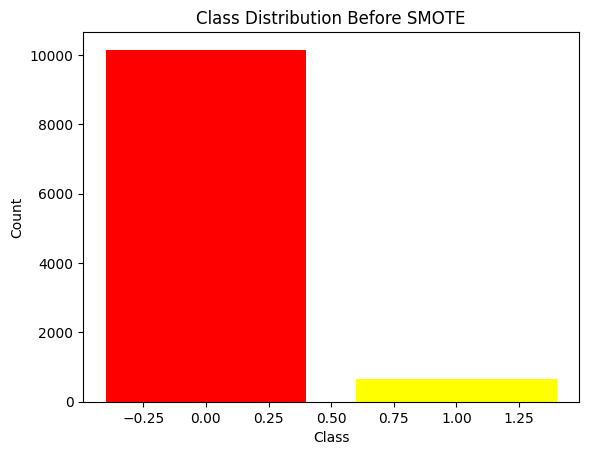

In [ ]:
plt.bar(Counter(y_train).keys(), Counter(y_train).values(), color=["red", "Yellow"])
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

**OVERSAMPLING_TECHNIQUE**

=== SMOTE ===
CONFUSION MATRIX
[[2915 1434]
 [  66  211]]
classification_report
              precision    recall  f1-score   support

           0       0.98      0.67      0.80      4349
           1       0.13      0.76      0.22       277

    accuracy                           0.68      4626
   macro avg       0.55      0.72      0.51      4626
weighted avg       0.93      0.68      0.76      4626

Class distribution after SMOTE: Counter({0: 10148, 1: 10148})


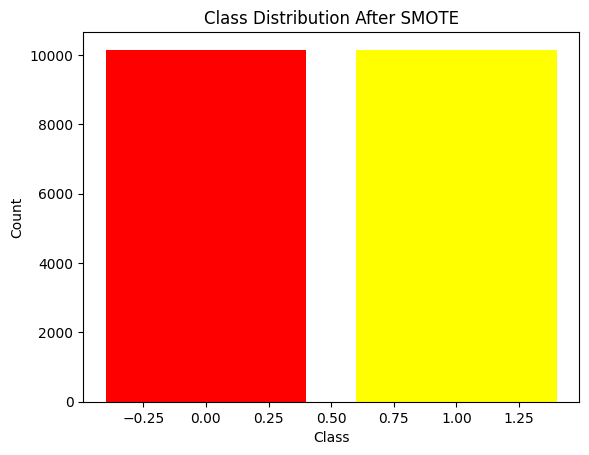

In [ ]:
# Apply SMOTE
smote = SMOTE(sampling_strategy="auto", random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
evaluate_model(X_train_smote, y_train_smote, X_test, y_test, "SMOTE")
#Class distribution after SMOTE
print("Class distribution after SMOTE:", Counter(y_train_smote))
plt.bar(Counter(y_train_smote).keys(), Counter(y_train_smote).values(), color=["red", "Yellow"])
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

** RANDOM OVERSAMPLING **

In [ ]:
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)
evaluate_model(X_ros, y_ros, X_test, y_test, "Random Oversampling")

=== Random Oversampling ===
CONFUSION MATRIX
[[2759 1590]
 [  47  230]]
classification_report
              precision    recall  f1-score   support

           0       0.98      0.63      0.77      4349
           1       0.13      0.83      0.22       277

    accuracy                           0.65      4626
   macro avg       0.55      0.73      0.50      4626
weighted avg       0.93      0.65      0.74      4626



In [ ]:
Counter(y_ros)

Counter({0: 10148, 1: 10148})

** ADESYN **

In [ ]:
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)
evaluate_model(X_adasyn, y_adasyn, X_test, y_test, "ADASYN")

=== ADASYN ===
CONFUSION MATRIX
[[2837 1512]
 [  61  216]]
classification_report
              precision    recall  f1-score   support

           0       0.98      0.65      0.78      4349
           1       0.12      0.78      0.22       277

    accuracy                           0.66      4626
   macro avg       0.55      0.72      0.50      4626
weighted avg       0.93      0.66      0.75      4626



In [ ]:
Counter(y_adasyn)

Counter({0: 10148, 1: 10307})

In [ ]:
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
evaluate_model(X_rus, y_rus, X_test, y_test, "Random Undersampling")

=== Random Undersampling ===
CONFUSION MATRIX
[[2906 1435]
 [  56  229]]
classification_report
              precision    recall  f1-score   support

          No       0.98      0.67      0.80      4341
         Yes       0.14      0.80      0.23       285

    accuracy                           0.68      4626
   macro avg       0.56      0.74      0.52      4626
weighted avg       0.93      0.68      0.76      4626



In [ ]:
Counter(y_rus)

Counter({'No': 638, 'Yes': 638})

In [ ]:
nm = NearMiss()
X_nm, y_nm = nm.fit_resample(X_train, y_train)
evaluate_model(X_nm, y_nm, X_test, y_test, "NearMiss")

=== NearMiss ===
CONFUSION MATRIX
[[1890 2451]
 [  58  227]]
classification_report
              precision    recall  f1-score   support

          No       0.97      0.44      0.60      4341
         Yes       0.08      0.80      0.15       285

    accuracy                           0.46      4626
   macro avg       0.53      0.62      0.38      4626
weighted avg       0.92      0.46      0.57      4626



In [ ]:
pd.Series(y_nm).value_counts()

,count
FraudFound,
No,638
Yes,638


Class distribution after Nearmiss: Counter({'No': 638, 'Yes': 638})


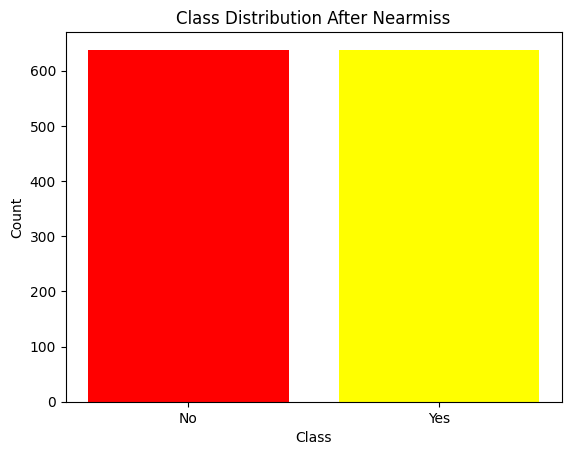

In [ ]:
print("Class distribution after Nearmiss:", Counter(y_nm))
plt.bar(Counter(y_nm).keys(), Counter(y_nm).values(), color=["red", "Yellow"])
plt.title("Class Distribution After Nearmiss")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

**Train using stand alone model**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

scores = cross_val_score(DecisionTreeClassifier(), X, y, cv=5)
scores

array([0.29020752, 0.74448768, 0.78437095, 0.85830091, 0.92444877])

In [ ]:
scores.mean()

np.float64(0.7203631647211415)

**Train using Bagging**

In [ ]:
from sklearn.ensemble import BaggingClassifier

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.8,
    oob_score=True,
    random_state=0
)
bag_model.fit(X_train, y_train)
bag_model.oob_score_

0.945988512136372

In [ ]:
bag_model.score(X_test, y_test)

0.9427150886294855

In [ ]:
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.8,
    oob_score=True,
    random_state=0
)
scores = cross_val_score(bag_model, X, y, cv=5)
scores

array([0.28793774, 0.81031128, 0.92736706, 0.93644617, 0.94163424])

In [ ]:
scores.mean()

np.float64(0.780739299610895)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

scores = cross_val_score(RandomForestClassifier(n_estimators=50), X, y, cv=5)
scores.mean()

np.float64(0.8774319066147861)

In [ ]:
import xgboost as xgb

In [ ]:
rf_xgb = xgb.XGBClassifier(
    max_depth=10,           # Increased depth for RF-like behavior
    learning_rate=0.1,      # Standard learning rate
    n_estimators=200,       # Number of trees (like RF)
    subsample=0.8,          # Row sampling (like RF)
    colsample_bytree=0.8,   # Column sampling (like RF)
    colsample_bylevel=0.8,  # Additional column sampling
    reg_alpha=0.1,          # L1 regularization
    reg_lambda=0.1,         # L2 regularization
    random_state=42,
    n_jobs=-1,              # Use all available cores
    tree_method='hist'      # Faster training method
)

In [ ]:
rf_xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.8, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
y_pred = rf_xgb.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4349
           1       0.89      0.31      0.46       277

    accuracy                           0.96      4626
   macro avg       0.92      0.65      0.72      4626
weighted avg       0.95      0.96      0.95      4626



In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[4338,   11],
       [ 191,   86]])

Text(0.5, 1.0, 'Confusion Matrix')

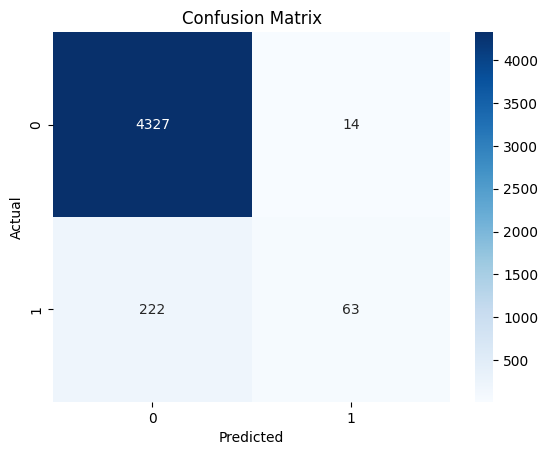

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')